Mean Absolute Error      : 0.5432
On average, the model is off by 0.54 stars.
--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      1 Star       0.46      0.58      0.52       243
     2 Stars       0.26      0.38      0.31       256
     3 Stars       0.34      0.41      0.38       414
     4 Stars       0.41      0.48      0.44       890
     5 Stars       0.85      0.68      0.76      2177

    accuracy                           0.58      3980
   macro avg       0.46      0.51      0.48      3980
weighted avg       0.63      0.58      0.60      3980

--- Confusion Matrix ---


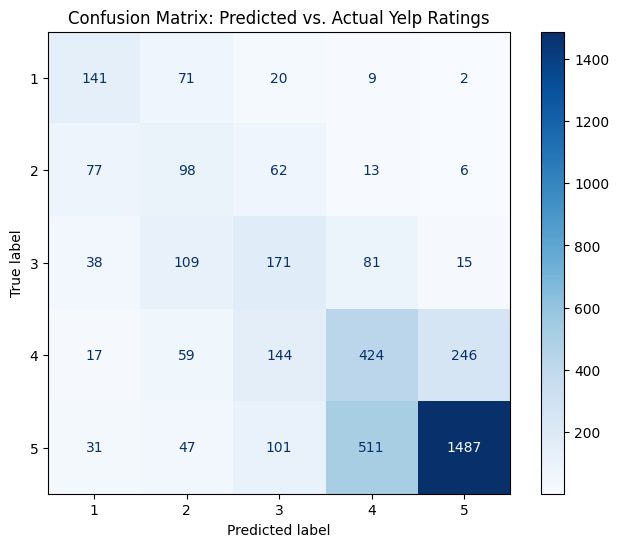

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("yelp_restaurant_reviews.csv").dropna(subset=["Review Text", "Rating"])
labels = (df["Rating"].values.astype(int) - 1)   # 0-based for pytorch
 
embeddings = np.load("embeddings_cache.npz")["embeddings"]
 
# Split and scale for training
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)
 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
 
# Fit the classifier, adjust for the smaller number of low ratings by weighting
# them more heavily in the loss function.
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)
 
# Evaluate on the test set
preds = clf.predict(X_test)
 
acc = accuracy_score(y_test, preds)
mae = np.abs(preds - y_test).mean()

# Print report.

print(f"Mean Absolute Error      : {mae:.4f}")
print(f"On average, the model is off by {mae:.2f} stars.")

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, preds, target_names=["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]))

print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["1", "2", "3", "4", "5"])

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs. Actual Yelp Ratings')
plt.show()